## Alternative routes over a simple network
In this notebook, we set up a basic simulation where two vessels move over a 1D network path. The network is setup as a square where each edge is 100 km long. All edges are bi-directional except one. We show how each each vessel follows a different route, because of the presence of a uni-directional edge. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd

# package(s) needed for plotting
import plotly.express as px

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID,
        opentnsim.core.Movable,      # allows the object to move, with a fixed speed, while logging this activity
    ), 
    {}
)

In [3]:
# make your preferred Node class out of available mix-ins.
Node = type(
    "Node", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID, 
        opentnsim.core.Locatable,    # allows the object to have a location
    ),
    {}
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a square network with four nodes and four edges, each 100 km long, one of which is uni-directional.

In [4]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [5]:
# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other three points 100 km apart to form a square
lon1, lat1, _ = geod.fwd(lon0, lat0,  0, 100000) # North from point 0
lon2, lat2, _ = geod.fwd(lon1, lat1, 90, 100000) # East from point 1
lon3, lat3, _ = geod.fwd(lon0, lat0, 90, 100000) # East from point 0

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
    "2": (lon2, lat2),
    "3": (lon3, lat3),
}

In [6]:
# create list of Node objects
nodes = []
for name, coord in coords.items():
    data_node = {
        "name": name,
        "geometry": Point(coord[0], coord[1])  # Point(longitude, latitude)
    }
    nodes.append(Node(**data_node))

In [7]:
# create list of edges
edges = [("0", "1"), ("1", "0"), # bi-directional edge
         ("1", "2"), ("2", "1"), # bi-directional edge
         ("2", "3"), ("3", "2"), # bi-directional edge
         ("0", "3")]             # uni-directional edge

In [8]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for node in nodes:
    FG.add_node(node.name, geometry=node.geometry)

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

In [9]:
# extract positions for plotting
positions = {node: (FG.nodes[node]["geometry"].x, FG.nodes[node]["geometry"].y) for node in FG.nodes}

# collect node labels
labels = {node: node for node in FG.nodes}

# compute edge labels as geodesic distances
edge_labels = {}
for u, v in FG.edges():
    lon1, lat1 = positions[u]
    lon2, lat2 = positions[v]
    _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
    edge_labels[(u, v)] = f"{int(dist)} m"

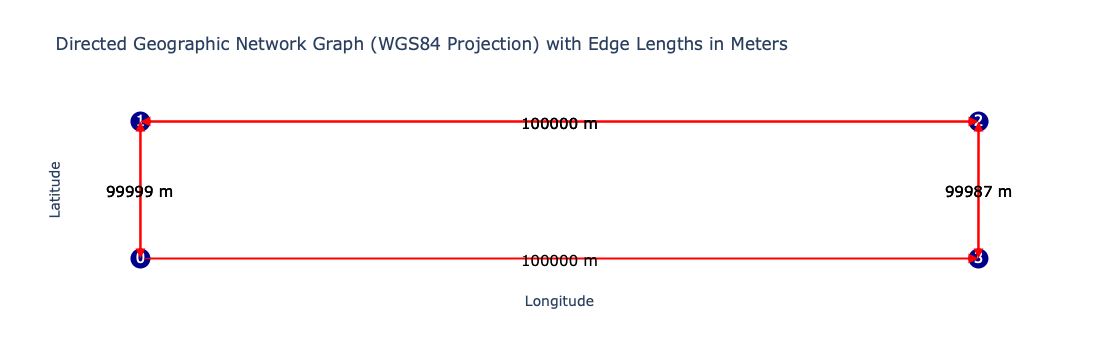

In [10]:
opentnsim.graph.plot_graph(FG)

#### 3. Run simulation

In [11]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [12]:
# create an empty list to store the vessels 
vessels = []

# collect paths in list
path_1 = nx.dijkstra_path(FG, "0", "3")
path_2 = nx.dijkstra_path(FG, "3", "0")
paths = [path_1, path_2]

# run a simulation for each path in the list
for index, path in enumerate(paths):

    # start simpy environment
    simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
    env = simpy.Environment(initial_time=simulation_start.timestamp())
    env.epoch = simulation_start

    # add graph to environment
    env.graph = FG
    
    # create vessel from dict 
    data_vessel = {
        "env": env,                                       # needed for simpy simulation
        "name": "Vessel" + '_on_Path_{}'.format(index),   # required by Identifiable
        "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
        "route": path,                                    # required by Routeable
        "v": 1,                                           # required by Movable, 1 m/s to verify distance and travel time
    }  # 
    vessel = Vessel(**data_vessel)
         
    # start the simulation
    env.process(mission(env, vessel))
    env.run()

    # store the vessel object, including its output, in the vessels list
    vessels.append(vessel)

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [13]:
for vessel in vessels:
    # load the logbook data into a dataframe
    df = pd.DataFrame.from_dict(vessel.logbook)
    
    print("'{}' logbook data:".format(vessel.name))  
    print('')
    
    display(df)

    trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
    trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])

    print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
    print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration))  
    print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
    print('')
    print('')
    

'Vessel_on_Path_0' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 3 start,2024-01-01 00:00:00,0,POINT (0 0)
1,Sailing from node 0 to node 3 stop,2024-01-02 03:46:40,0,POINT (0.8983152841195217 0)


'Vessel_on_Path_0' travelled a distance of 100000.0 meters
'Vessel_on_Path_0' took 100000.0 seconds to arrive at its destination
'Vessel_on_Path_0' travelled at an average speed of 1.0 meters per second


'Vessel_on_Path_1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 3 to node 2 start,2024-01-01 00:00:00.000000,0,POINT (0.8983152841195217 0)
1,Sailing from node 3 to node 2 stop,2024-01-02 03:46:27.626318,0,POINT (0.8984264319755021 0.9042568124693914)
2,Sailing from node 2 to node 1 start,2024-01-02 03:46:27.626318,0,POINT (0.8984264319755021 0.9042568124693914)
3,Sailing from node 2 to node 1 stop,2024-01-03 07:33:07.626318,0,POINT (0 0.9043687229127633)
4,Sailing from node 1 to node 0 start,2024-01-03 07:33:07.626318,0,POINT (0 0.9043687229127633)
5,Sailing from node 1 to node 0 stop,2024-01-04 11:19:47.626318,0,POINT (0 0)


'Vessel_on_Path_1' travelled a distance of 299987.6 meters
'Vessel_on_Path_1' took 299987.6 seconds to arrive at its destination
'Vessel_on_Path_1' travelled at an average speed of 1.0 meters per second




The inspection of the logbook data shows that the first vessel moved from its origin (*Node 0*) directly to its destination (*Node 3*). The second vessel moved from its origin (*Node 3*) to its destination (*Node 0*), but while doing so was passing *Node 2* and *Node 1* in the process. This show that indeed the edge between *Node 0* and *Node 3* is uni-directional.

The print statements show that the length of the route from *Node 3* to *Node 3* is not exactly 300 km. This is primarily due to the fact that Edge '0 - 1' and Edge '2 - 3' are not exactly 100 km (see also the graph plot above). This is one of the issues that can occur when using coordinate projections. 

In [14]:
# TODO: naar de package verplaatsen - mogelijk in een log module plaatsen
def logbook_to_eventtable(objs):
    """Method to transform object logbook, that contains a list of activity start/stop logs, into a 'minimum event table'. 
    
    This method implements the basic 'event table' concept as proposed by Van der Werff:

    Van der Werff, S.E., F. Baart and M. van Koningsveld (2025). “Merging Multiple System Perspectives: The Key to 
    Effective Inland Shipping Emission-Reduction Policy Design.” Journal of Marine Science and engineering 13(4), 716. 
    https://doi.org/10.3390/jmse13040716 

    Van der Werff, S.E., S. Eppenga, A. van der Hout, F. Baart and M. van Koningsveld (2025). “Multi-perspective 
    nautical safety risk assessment of allisions with offshore wind parks.” Applied Ocean Research 158(2025),104564. 
    https://doi.org/10.1016/j.apor.2025.104564 

    For waterborne traffic travelling over a water transport network, a unique event is defined by a combination of: 
     - a unique vessel, 
     - that travels a specific section of the waterway, 
     - at a specific time.

    Parameters
    ----------
    objs: list
        list of OpenTNSim simulation objects that have log information

    Returns
    -------
    df: pandas.DataFrame
        dataframe that contains all events encapsulated in the obj.logbook attributes in the input list of objs
    """
    
    events = []
    for obj in objs:
        df = pd.DataFrame.from_dict(obj.logbook)
        for i in range(0, len(df), 2):
            activity = df.iloc[i]['Message'].replace(' start', '')
            
            start_time = df.iloc[i]['Timestamp']
            stop_time = df.iloc[i+1]['Timestamp']
            start_location = df.iloc[i]['Geometry']
            stop_location = df.iloc[i+1]['Geometry']
            
            duration_seconds = (stop_time - start_time).total_seconds()
            distance_meters = opentnsim.graph.calculate_distance(start_location, stop_location)
            
            events.append({
                'object id': obj.id,
                'object name': obj.name,
                'activity name': activity,
                'start location': start_location,
                'stop location': stop_location,
                'start time': start_time,
                'stop time': stop_time,
                'distance (m)': distance_meters,
                'duration (s)': duration_seconds,
            })
        
    # Final DataFrame
    df = pd.DataFrame(events)
    
    return df

In [15]:
df_eventtable = logbook_to_eventtable(vessels)
df_eventtable

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,75a63b0e-eb70-4720-9583-2475647863f6,Vessel_on_Path_0,Sailing from node 0 to node 3,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00.000000,2024-01-02 03:46:40.000000,100000.000000,100000.000000
1,971c9594-2ca0-4a3c-997d-691814c9fc10,Vessel_on_Path_1,Sailing from node 3 to node 2,POINT (0.8983152841195217 0),POINT (0.8984264319755021 0.9042568124693914),2024-01-01 00:00:00.000000,2024-01-02 03:46:27.626318,99987.626318,99987.626318
2,971c9594-2ca0-4a3c-997d-691814c9fc10,Vessel_on_Path_1,Sailing from node 2 to node 1,POINT (0.8984264319755021 0.9042568124693914),POINT (0 0.9043687229127633),2024-01-02 03:46:27.626318,2024-01-03 07:33:07.626318,100000.000000,100000.000000
3,971c9594-2ca0-4a3c-997d-691814c9fc10,Vessel_on_Path_1,Sailing from node 1 to node 0,POINT (0 0.9043687229127633),POINT (0 0),2024-01-03 07:33:07.626318,2024-01-04 11:19:47.626318,100000.000000,100000.000000


In [16]:
def generate_vessel_gantt_chart(df_eventtable: pd.DataFrame):
    """Method to generate a Gantt chart from a vessel activity log DataFrame.

    This method visualizes the activity timeline of vessels by combining vessel names and activity types into a single label,
    and plotting them using Plotly Express's timeline chart. 

    Parameters
    ----------
    df_eventtable : pandas.DataFrame
        DataFrame containing columns 'object name', 'activity name', 'start time', and 'stop time' representing vessel activity logs.

    Returns
    -------
    fig : plotly.graph_objects.Figure
        A Plotly figure object representing the Gantt chart of vessel activities.
    """
    
    # Add vessel name to activity label
    df_eventtable['activity label'] = df_eventtable['object name'] + ' - ' + df_eventtable['activity name']

    # Create the Gantt chart
    fig = px.timeline(
        df_eventtable,
        x_start="start time",
        x_end="stop time",
        y="activity label",
        color="object name",
        title="Gantt chart of logged events"
    )

    # Reverse the Y-axis to match Gantt chart style
    fig.update_yaxes(autorange="reversed")

    # Customize layout
    fig.update_layout(
        xaxis_title="Time",
        yaxis_title="Activity (with Vessel)",
        legend_title="Vessel",
        margin=dict(l=20, r=20, t=40, b=20)
    )

    return fig

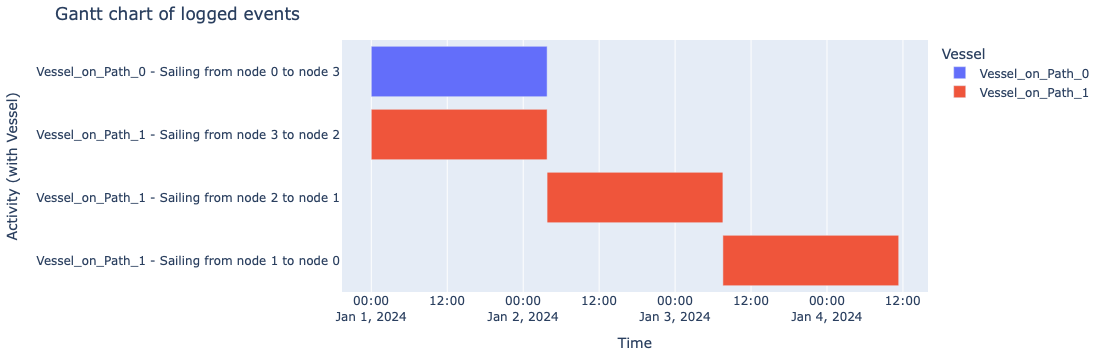

In [17]:
generate_vessel_gantt_chart(df_eventtable)